# Customer Value Assessment · Customer-Base Audit

**Engagement deliverable** — UCI Online Retail II (noncontractual EU giftware retail; revenue-only).

This assessment establishes the order-level customer×time view before any CLV fit. We characterize the base, quantify concentration and retention dynamics, and export reusable audit tables consumed by weekly CLV (`01-clv`).

| Part | Scope | Focus |
|------|-------|-------|
| **A — Commercial views** | Acquisition · Frequency · Monetary · Duration · Heterogeneity | Client-facing health brief |
| **B — Five Lenses** | Framework of Fader, Hardie & Ross | Period / cohort diagnostics for planning |

**Setting:** noncontractual retail (no cancel date). **Grain:** **order** (invoice), not line item. **Metric:** revenue only (no COGS / margin).

**Data prerequisite:** `python scripts/uci_pipeline.py` → `data/modeling/uci_fact_transactions.parquet`.  
**Downstream:** `Notebooks/01-clv.ipynb` (weekly BG/NBD + Gamma-Gamma).


## Setup

Configures the plotting stack, resolves the project root, creates `data/modeling/audit/`, and imports construction helpers from `scripts/customer_base_audit.py`.

Construction logic lives in that module so this deliverable stays readable and smoke tests reuse the same functions.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in (path, *path.parents):
        if (candidate / "scripts" / "uci_pipeline.py").exists():
            return candidate
    return path


PROJECT_ROOT = find_project_root()
DATA = PROJECT_ROOT / "data" / "modeling"
AUDIT = DATA / "audit"
AUDIT.mkdir(parents=True, exist_ok=True)

import sys
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from customer_base_audit import (
    active_survival_by_tenure_weeks,
    attach_acquisition,
    build_customer_master,
    build_orders,
    cohort_evolution,
    duration_snapshot,
    ever_repeat_rate,
    export_audit_summaries,
    frequency_distribution,
    interpurchase_gaps,
    load_fact_transactions,
    monetary_concentration,
    monthly_acquisition,
    multiplicative_decomposition,
    new_vs_repeat_orders,
    period_active_customers,
    period_vs_period,
    repeat_buying_rate,
    same_customer_up_down,
    second_purchase_cumulative,
    stacked_active_by_cohort,
    vtd_deciles,
    whale_curve,
)

print("Setup complete · audit dir:", AUDIT)


Setup complete · audit dir: C:\Users\ahmed\Desktop\Projects\CLV\data\modeling\audit


## Order spine and audit exports

Foundation for every view below and for weekly CLV. Three transforms, then exports.

### Approach

```text
uci_fact_transactions.parquet     (line grain — one SKU row per invoice line)
        │  load_fact_transactions()
        ▼
      fact                        customer_id, order_id, order_date, line_total, …
        │  build_orders()
        ▼
     orders                       one row per invoice
                                  spend = sum(line_total), n_lines, order_date = min(line dates)
        │  attach_acquisition()
        ▼
orders + acquisition_date         first-ever order date per customer
       + cohort_id                quarterly cohort of that first order (e.g. 2010Q4)
```

**Why order grain?** Frequency models count **purchases** (invoices), not line items; monetary models work on average **order** spend. Line grain would inflate frequency and distort AOV.

### Audit exports (`export_audit_summaries`)

Under `data/modeling/audit/`:

| Key | File | Grain | Role |
|-----|------|-------|------|
| `orders` | `uci_orders.parquet` | order | Primary spine for this assessment **and** `01-clv` |
| `lifetime` | `uci_customer_lifetime.parquet` | customer | Lifetime orders, spend, AOV, one-time flag |
| `master` | `uci_customer_master.parquet` | customer | Tenure, age, recency, gaps (commercial portrait) |
| `acquisition` | `uci_monthly_acquisition.parquet` | month | New customers + cumulative base |
| `panel_Q` | `uci_customer_period_Q.parquet` | customer × quarter | Who was active / spent how much |
| `stacked_Q` | `uci_active_by_cohort_Q.parquet` | cohort × period | Stacked base for Lens 5 |
| `lens1` | `uci_lens1_summary.parquet` | 1 row | Last full-year health snapshot |
| `whale` | `uci_whale_curve.parquet` | rank curve | Revenue concentration |

### Master customer table

`build_customer_master(orders)` → **one row per customer**: first/last purchase, revenue, tenure, customer age, recency, AOV, mean interpurchase gap, one-time buyer. Core input to Part A.


In [2]:
fact = load_fact_transactions(DATA / "uci_fact_transactions.parquet")
orders = attach_acquisition(build_orders(fact))
print(f"Lines: {len(fact):,} → Orders: {len(orders):,} · Customers: {orders['customer_id'].nunique():,}")
print(f"Span: {orders['order_date'].min().date()} → {orders['order_date'].max().date()}")
display(orders.head())

paths = export_audit_summaries(PROJECT_ROOT, orders=orders)
print("Exported:")
for k, p in paths.items():
    print(f"  {k}: {p.relative_to(PROJECT_ROOT)}")

master = build_customer_master(orders)
print(f"Master customer table: {len(master):,} rows")
display(master.head())


Lines: 798,626 → Orders: 36,684 · Customers: 5,798
Span: 2009-12-01 → 2011-12-09


,customer_id,order_id,order_date,spend,n_lines,acquisition_date,cohort_id
0,12346,491725,2009-12-14 08:34:00,45.0,1,2009-12-14 08:34:00,2009Q4
1,12346,491742,2009-12-14 11:00:00,22.5,1,2009-12-14 08:34:00,2009Q4
2,12346,491744,2009-12-14 11:02:00,22.5,1,2009-12-14 08:34:00,2009Q4
3,12346,492718,2009-12-18 10:47:00,22.5,1,2009-12-14 08:34:00,2009Q4
4,12346,492722,2009-12-18 10:55:00,1.0,1,2009-12-14 08:34:00,2009Q4


Exported:
  orders: data\modeling\audit\uci_orders.parquet
  lifetime: data\modeling\audit\uci_customer_lifetime.parquet
  master: data\modeling\audit\uci_customer_master.parquet
  acquisition: data\modeling\audit\uci_monthly_acquisition.parquet
  panel_Q: data\modeling\audit\uci_customer_period_Q.parquet
  stacked_Q: data\modeling\audit\uci_active_by_cohort_Q.parquet
  lens1: data\modeling\audit\uci_lens1_summary.parquet
  whale: data\modeling\audit\uci_whale_curve.parquet
Master customer table: 5,798 rows


,customer_id,first_purchase,last_purchase,n_orders,revenue,cohort_id,tenure_days,tenure_weeks,customer_age_days,customer_age_weeks,recency_days,recency_weeks,aov,mean_interpurchase_days,is_one_time_buyer
0,18102,2009-12-01 09:24:00,2011-12-09 11:50:00,145,608821.65,2009Q4,738,105.43,738,105.43,0,0.00,4198.770000,4.868056,0
1,14646,2009-12-02 16:52:00,2011-12-08 12:12:00,151,528602.52,2009Q4,735,105.00,736,105.14,1,0.14,3500.678940,4.580000,0
2,14156,2009-12-01 12:30:00,2011-11-30 10:54:00,156,313946.37,2009Q4,728,104.00,738,105.43,9,1.29,2012.476731,4.283871,0
3,14911,2009-12-01 11:41:00,2011-12-08 15:54:00,398,295972.63,2009Q4,737,105.29,738,105.43,0,0.00,743.649824,1.471033,0
4,17450,2010-09-27 16:59:00,2011-12-01 13:29:00,51,246973.09,2010Q3,429,61.29,437,62.43,7,1.00,4842.609608,8.300000,0


### Master customer table — definitions

| | |
|--|--|
| **Name** | `master` (also `data/modeling/audit/uci_customer_master.parquet`) |
| **Grain** | **One row per customer** (`customer_id`) |
| **Source** | Order spine (`orders`) as of the latest `order_date` in the data |
| **Role** | Commercial “who is this base?” portrait — lifetime view for Part A (frequency, monetary, duration, heterogeneity). Not a model scorecard; forward CLV lives in notebook `01`. |

#### Columns

| Column | Definition |
|--------|------------|
| `customer_id` | Unique customer key |
| `first_purchase` | Date of first order (acquisition) |
| `last_purchase` | Date of most recent order |
| `n_orders` | Lifetime count of distinct invoices |
| `revenue` | Lifetime spend = sum of order `spend` |
| `cohort_id` | Acquisition cohort = calendar quarter of `first_purchase` (e.g. `2010Q4`) |
| `tenure_days` / `tenure_weeks` | Time between first and last purchase (0 for one-time buyers) |
| `customer_age_days` / `customer_age_weeks` | Time from first purchase to observation end |
| `recency_days` / `recency_weeks` | Time from last purchase to observation end |
| `aov` | Average order value = `revenue / n_orders` |
| `mean_interpurchase_days` | Mean days between consecutive orders (null / NA if only one order) |
| `is_one_time_buyer` | 1 if `n_orders == 1`, else 0 |

**Tenure vs age vs recency:** tenure = active span; age = calendar time since acquisition; recency = silence since last buy. In noncontractual retail there is no cancel date — recency is the practical “still engaged?” signal.


### Key metrics — AOV and AOF

Defined once; used throughout Parts A and B.

| Acronym | Full name | Formula | Commercial read |
|---------|-----------|---------|-----------------|
| **AOV** | Average Order Value | `spend ÷ n_orders` | Typical £ **per invoice** |
| **AOF** | Average Order Frequency | `n_orders ÷ n_buyers` (in a period, among actives) | Typical **orders per buyer** active in that window |

**Multiplicative check (Lens 1):**  
`total revenue ≈ (# buyers) × AOF × AOV`

**Scope:**
- On the **master** table, `aov` is **lifetime** AOV for that customer.
- In **Lens 1 / 3 / 4**, AOV and AOF are computed **inside a period** (or among that period’s actives), not over the full life.


## Part A · Commercial views

Client-facing health check in fixed order: **how we grow the base → how often they buy → how much they spend → how long they stay → how unequal they are.**

These views are **descriptive** (no holdout, no model). Part B reframes the same spine with period and cohort diagnostics from the Five Lenses framework.


### A1 — Acquisition

**Focus:** Are we still adding customers, and is growth coming from first orders or from the existing base?

| Object | Approach | Implication |
|--------|----------|-------------|
| `monthly_acquisition` | First order → calendar month; new IDs; running cumulative | Seasonality, acquisition droughts, cumulative base slope |
| `new_vs_repeat_orders` | Rank each customer’s orders; flag first-ever; roll up by month | Share of volume that is trial vs repeat |

Left: bars = new customers that month; line = cumulative base.  
Right: first-ever invoices vs repeat invoices by month.


,acq_month,n_new,cumulative_customers
13,2011-01,70,4353
14,2011-02,122,4475
15,2011-03,178,4653
16,2011-04,102,4755
17,2011-05,110,4865
18,2011-06,107,4972
19,2011-07,101,5073
20,2011-08,103,5176
21,2011-09,188,5364
22,2011-10,216,5580


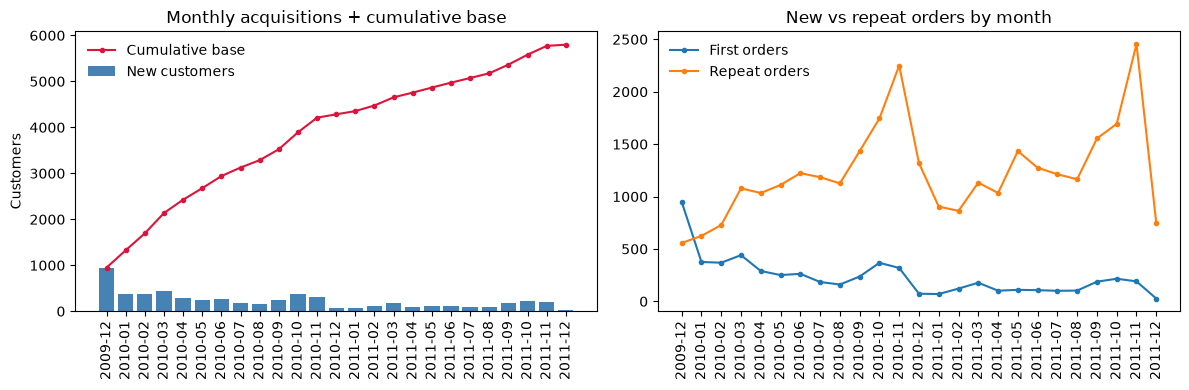

In [3]:
acq = monthly_acquisition(orders)
nvr = new_vs_repeat_orders(orders)
display(acq.tail(12))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(acq["acq_month"], acq["n_new"], color="steelblue", label="New customers")
axes[0].plot(acq["acq_month"], acq["cumulative_customers"], color="crimson", marker="o", ms=3, label="Cumulative base")
axes[0].set_title("Monthly acquisitions + cumulative base")
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_ylabel("Customers")
axes[0].legend(frameon=False)

axes[1].plot(nvr["month"], nvr["n_first_orders"], label="First orders", marker="o", ms=3)
axes[1].plot(nvr["month"], nvr["n_repeat_orders"], label="Repeat orders", marker="o", ms=3)
axes[1].set_title("New vs repeat orders by month")
axes[1].tick_params(axis="x", rotation=90)
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()


#### Assessment — A1

- Base grows from **~950** in Dec 2009 to **5,798** by Dec 2011; early months are front-loaded (partial first month + launch effects).
- By late 2011, **repeat orders dominate** volume (e.g. Nov 2011: ~7% of orders are first-ever; Dec is even lower). Growth of the *order book* is increasingly a retention story, not pure acquisition.
- Monthly new-customer bars stay positive but smaller than the opening spike — the cumulative line keeps rising without requiring Dec-2009-scale acquisition every month.

**Implication:** healthy shift toward a repeat-driven order mix; acquisition still matters to refresh the base (see Lens 5 / planning sketch).


### A2 — Buying frequency

**Focus:** How often do customers repurchase, and how long between orders?

| Object | Approach | Implication |
|--------|----------|-------------|
| `frequency_distribution` | Lifetime `n_orders` per customer from the order spine | Median vs mean; one-time buyer share |
| `interpurchase_gaps` | Days between consecutive orders (multi-order customers only) | Typical repurchase cadence; supports weekly time unit for CLV |

Heavy right skew is expected in retail — most people buy once or twice; a thin tail buys often. That heterogeneity is the commercial case for a probabilistic frequency model in `01`.


Orders/customer — median=3 · mean=6.3
One-time buyers: 27.5%
Interpurchase days — median=24 · mean=51


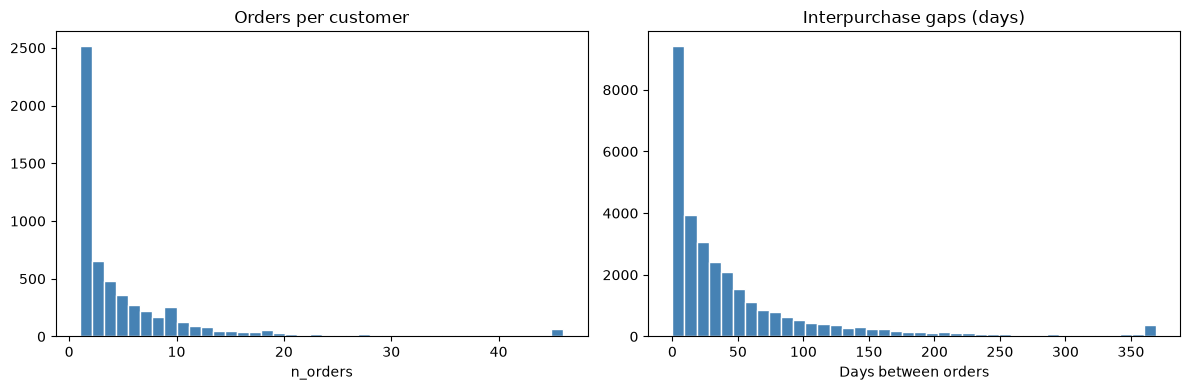

In [4]:
freq_df = frequency_distribution(orders)
gaps = interpurchase_gaps(orders)
print(f"Orders/customer — median={freq_df['n_orders'].median():.0f} · mean={freq_df['n_orders'].mean():.1f}")
print(f"One-time buyers: {freq_df['is_one_time_buyer'].mean():.1%}")
print(f"Interpurchase days — median={gaps.median():.0f} · mean={gaps.mean():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(freq_df["n_orders"].clip(upper=freq_df["n_orders"].quantile(0.99)), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Orders per customer")
axes[0].set_xlabel("n_orders")
axes[1].hist(gaps.clip(upper=gaps.quantile(0.99)), bins=40, color="steelblue", edgecolor="white")
axes[1].set_title("Interpurchase gaps (days)")
axes[1].set_xlabel("Days between orders")
plt.tight_layout()
plt.show()


#### Assessment — A2

- **Median 3 orders**, mean **~6.3** — right skew (a thin heavy-buyer tail pulls the mean up).
- **~27% one-time buyers** over the full window — most of the base does repeat at least once, but a sizable trial-only share remains.
- Interpurchase gaps: median **~24 days**, mean **~51 days** — weekly time units for BG/NBD are a natural operational fit.

**Implication:** “average customer” frequency is misleading; heterogeneity in buy rate is the modeling problem Part B and notebook `01` address.


### A3 — Monetary value

**Focus:** How concentrated is lifetime revenue? How dependent are we on a thin high-value tier?

| Object | Approach | Implication |
|--------|----------|-------------|
| `monetary_concentration` | Rank by lifetime spend; top 1% / 10% shares; % of base for half of revenue | Dependence on the whale tier |
| `whale_curve` | Lorenz-style curve: richest customers first → cumulative % revenue | Steep early rise = high concentration |

Uses the **master** table (`revenue` = lifetime order spend). Same concentration logic as Lens 1, but over the **full** observed life, not one calendar year.


Customers: 5,798
Top 1% spend share: 31.6%
Top 10% spend share: 63.8%
Bottom 90% spend share: 36.2%
% customers for 50% revenue: 4.4%


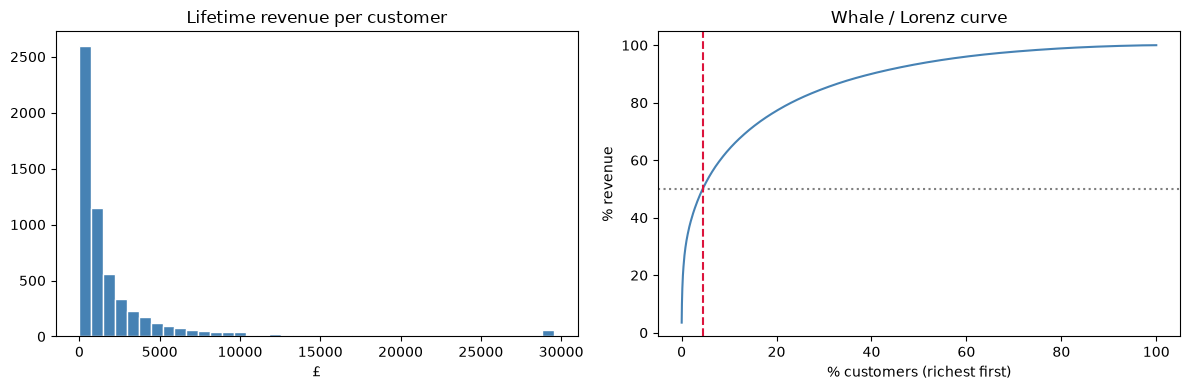

In [5]:
conc = monetary_concentration(orders)
print(f"Customers: {conc['n_customers']:,.0f}")
print(f"Top 1% spend share: {conc['top1_share']:.1%}")
print(f"Top 10% spend share: {conc['top10_share']:.1%}")
print(f"Bottom 90% spend share: {conc['bottom90_share']:.1%}")
print(f"% customers for 50% revenue: {conc['pct_customers_for_half_revenue']:.1f}%")

life = master
whale = whale_curve(life["revenue"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(life["revenue"].clip(upper=life["revenue"].quantile(0.99)), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Lifetime revenue per customer")
axes[0].set_xlabel("£")
axes[1].plot(whale["pct_customers"], whale["pct_revenue"], color="steelblue")
axes[1].axhline(50, color="gray", ls=":")
axes[1].axvline(whale.attrs.get("pct_customers_for_half_revenue", 0), color="crimson", ls="--")
axes[1].set_xlabel("% customers (richest first)")
axes[1].set_ylabel("% revenue")
axes[1].set_title("Whale / Lorenz curve")
plt.tight_layout()
plt.show()


#### Assessment — A3

- **Top 1%** of customers ≈ **32%** of lifetime revenue; **top 10%** ≈ **64%**.
- Only about **~4.5%** of customers deliver **half** of all revenue (steep whale / Lorenz curve).
- Bottom 90% still matter for volume and future CLV optionality, but equity is highly concentrated.

**Implication:** retention and win-back on the whale tier move the £ needle far more than average-customer campaigns. CLV segmentation in `01` should respect this skew.


### A4 — Relationship duration

**Focus:** How long do relationships last, and how “alive” does the base look without a cancel date?

Noncontractual retail has **no churn event**. Proxies used:

| Object | Approach | Implication |
|--------|----------|-------------|
| `duration_snapshot` | From master: tenure, recency; `still_active` = purchase in last **13 weeks** | Share of base recently active; median silence |
| `active_survival_by_tenure_weeks` | For each week w since acquisition, % of base with a purchase in [w, w+13) weeks | Decay of activity after trial (descriptive proxy, not a formal survival model) |

Recency (weeks since last order) feeds BG/NBD’s tx, T construction in notebook `01`.


Still active (purchase in last 13 weeks): 49.8%
Recency weeks — median=13.3
Tenure weeks — median=31.9


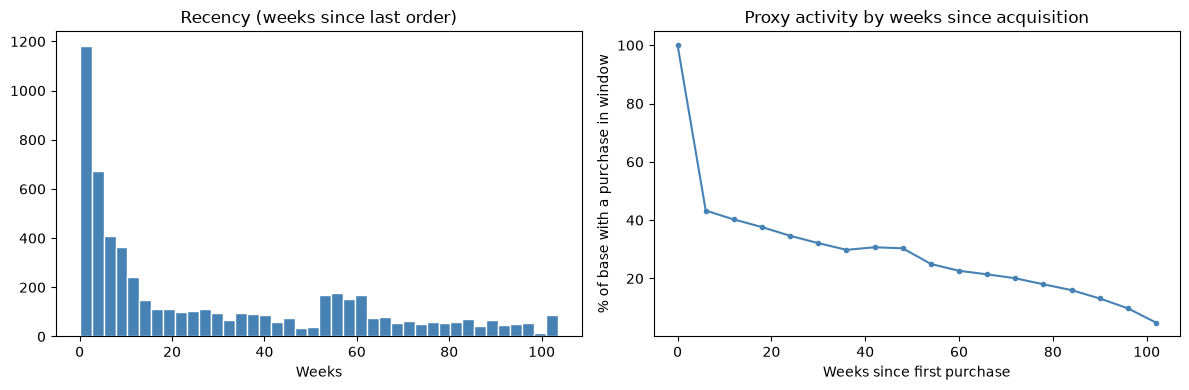

In [6]:
dur = duration_snapshot(orders, active_within_weeks=13)
print(f"Still active (purchase in last 13 weeks): {dur['still_active'].mean():.1%}")
print(f"Recency weeks — median={dur['recency_weeks'].median():.1f}")
print(f"Tenure weeks — median={dur['tenure_weeks'].median():.1f}")

surv = active_survival_by_tenure_weeks(orders, max_weeks=104, window_weeks=13)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dur["recency_weeks"].clip(upper=dur["recency_weeks"].quantile(0.99)), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Recency (weeks since last order)")
axes[0].set_xlabel("Weeks")
axes[1].plot(surv["week"], surv["pct_active"], marker="o", ms=3, color="steelblue")
axes[1].set_title("Proxy activity by weeks since acquisition")
axes[1].set_xlabel("Weeks since first purchase")
axes[1].set_ylabel("% of base with a purchase in window")
plt.tight_layout()
plt.show()


#### Assessment — A4

- About **half** the base (~50%) bought in the last **13 weeks** (“still active” proxy) — the other half is silent under that rule.
- Median **recency ~13 weeks**; median **tenure ~32 weeks** (first→last order span). Many relationships are short or intermittent.
- Activity-by-weeks-since-acquisition decays after trial, with seasonal bumps later (giftware Q4 reactivation shows up again in Lens 5).

**Implication:** no cancel date → “alive vs dead” is probabilistic. Recency + frequency (not a binary churn flag) is the right language into BG/NBD.


### A5 — Customer heterogeneity

**Focus:** Is there an “average customer,” or are value and activity badly skewed?

Scatter plots from the **master** table (clipped at p99 for readability):

| Plot | Axes | Commercial read |
|------|------|-----------------|
| Frequency vs monetary | Orders × lifetime £ | High spenders are not always high frequency (and vice versa) |
| Recency vs frequency | Weeks silent × orders | Recent buyers and heavy buyers are different slices |

Tight, oval clouds would support a single mean CLV. They are not — so Part B and notebook `01` treat customers as draws from a heterogeneous population.


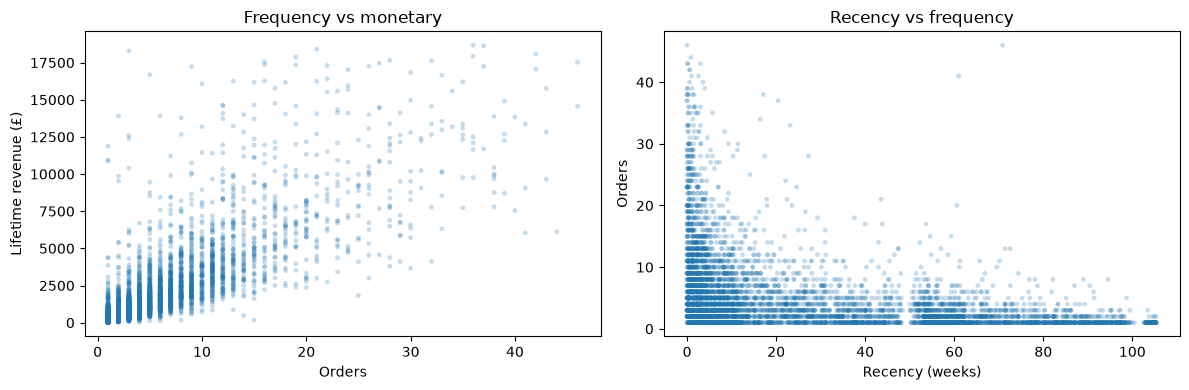

There is no average customer — value and activity are highly skewed.


In [7]:
plot_df = master.copy()
plot_df = plot_df[plot_df["n_orders"] <= plot_df["n_orders"].quantile(0.99)]
plot_df = plot_df[plot_df["revenue"] <= plot_df["revenue"].quantile(0.99)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(plot_df["n_orders"], plot_df["revenue"], alpha=0.25, s=12, edgecolors="none")
axes[0].set_xlabel("Orders")
axes[0].set_ylabel("Lifetime revenue (£)")
axes[0].set_title("Frequency vs monetary")
axes[1].scatter(plot_df["recency_weeks"], plot_df["n_orders"], alpha=0.25, s=12, edgecolors="none")
axes[1].set_xlabel("Recency (weeks)")
axes[1].set_ylabel("Orders")
axes[1].set_title("Recency vs frequency")
plt.tight_layout()
plt.show()
print("There is no average customer — value and activity are highly skewed.")


#### Assessment — A5

- Frequency vs revenue is a wide cloud: high spenders are not always the highest-frequency buyers, and vice versa.
- Recency vs frequency shows recent buyers and historically heavy buyers as overlapping but distinct slices — silence ≠ low lifetime value for everyone.

**Implication:** one KPI (“VIP = high AOV”) will mis-rank customers. Need joint frequency × monetary (and later expected purchases × CLV) views.


## Part B · Five Lenses (Fader, Hardie & Ross)

We structure the temporal diagnostics using the **Five Lenses** framework of Peter Fader, Bruce Hardie, and Michael Ross (*The Customer-Base Audit*)—the standard approach for noncontractual bases. Attribution for the lens design; analysis and commercial conclusions below are ours on this retailer’s order history.

| Lens | Diagnostic |
|------|------------|
| 1 | Heterogeneity of buyers **within a period** |
| 2 | Change **period vs period** (retain / lapse / replace) |
| 3 | Evolution of **one acquisition cohort** |
| 4 | **Cohort vs cohort** (size-normalized) |
| 5 | Overall **base health** (stacked actives + planning sketch) |

Still descriptive. Forward customer value is deferred to `01-clv`.


### Lens 1 — Within-period heterogeneity

**Window:** last **full calendar year** in the data (if the series ends mid-year, use the prior complete year).

| Step | Approach | Output |
|------|----------|--------|
| Restrict to year | `period_active_customers` | Customers with ≥1 order in the year + period spend / orders / AOV |
| Decompose revenue | `multiplicative_decomposition` | n buyers × AOF × AOV = total spend; % one-order |
| Concentration | `whale_curve` on period spend | % of buyers who deliver 50% of period revenue |

**Commercial read:** mean ≫ median spend → no average customer. High one-order % → weak within-period repeat.


Lens 1 period: 2011-01-01 → 2011-12-31
Active customers: 4,170
Total spend: £8,101,676
AOF (orders / buyer): 4.07 · AOV: £476.93
% one-order in period: 35.5%
% customers for 50% of revenue: 5.2%
There is no 'average customer' — spend is right-skewed.


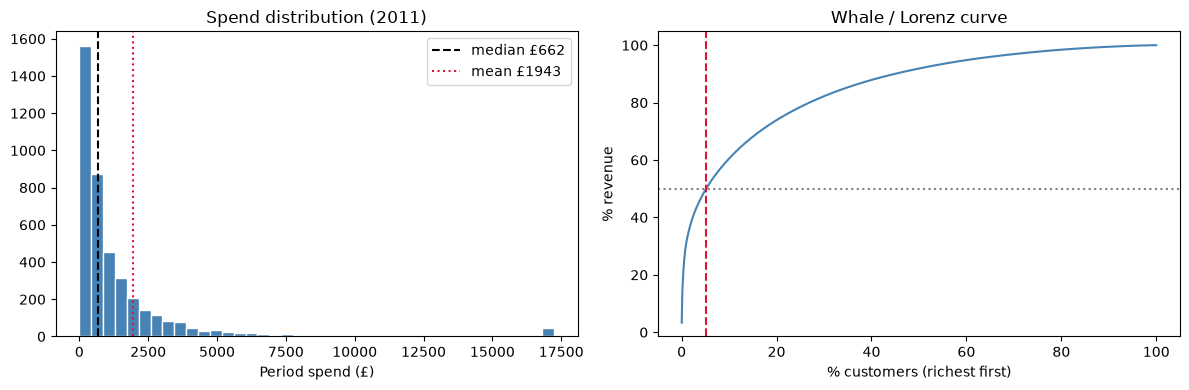

In [8]:
max_d = orders["order_date"].max()
year = int(max_d.year) - (1 if max_d.month < 12 else 0)
p1_start, p1_end = pd.Timestamp(f"{year}-01-01"), pd.Timestamp(f"{year}-12-31")
active = period_active_customers(orders, p1_start, p1_end)
decomp = multiplicative_decomposition(active)
whale = whale_curve(active["spend"])

print(f"Lens 1 period: {p1_start.date()} → {p1_end.date()}")
print(f"Active customers: {decomp['n_buyers']:,.0f}")
print(f"Total spend: £{decomp['total_spend']:,.0f}")
print(f"AOF (orders / buyer): {decomp['aof']:.2f} · AOV: £{decomp['aov']:.2f}")
print(f"% one-order in period: {decomp['pct_one_order']:.1f}%")
print(f"% customers for 50% of revenue: {whale.attrs.get('pct_customers_for_half_revenue', float('nan')):.1f}%")
print("There is no 'average customer' — spend is right-skewed.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(active["spend"].clip(upper=active["spend"].quantile(0.99)), bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(active["spend"].median(), color="black", ls="--", label=f"median £{active['spend'].median():.0f}")
axes[0].axvline(active["spend"].mean(), color="crimson", ls=":", label=f"mean £{active['spend'].mean():.0f}")
axes[0].set_title(f"Spend distribution ({year})")
axes[0].set_xlabel("Period spend (£)")
axes[0].legend()

axes[1].plot(whale["pct_customers"], whale["pct_revenue"], color="steelblue")
axes[1].axhline(50, color="gray", ls=":")
axes[1].axvline(whale.attrs.get("pct_customers_for_half_revenue", 0), color="crimson", ls="--")
axes[1].set_xlabel("% customers (richest first)")
axes[1].set_ylabel("% revenue")
axes[1].set_title("Whale / Lorenz curve")
plt.tight_layout()
plt.show()


#### Assessment — Lens 1 (calendar year 2011)

- **~4,170** buyers; total spend **~£8.1M**; AOF **~4.1** orders/buyer; AOV **~£477**.
- **~36%** of period buyers are **one-order** in-year — within-period repeat is limited for a large slice.
- Mean spend ≫ median (histogram); **~5%** of buyers deliver **50%** of 2011 revenue.

**Implication:** even inside one year, there is no average customer — concentration and one-order share argue against naive per-head averages for planning.


### Lens 2 — Period-over-period change

**Window:** Lens-1 year (**B**) vs the prior calendar year (**A**), clipped to observed data.

| Metric | Definition |
|--------|------------|
| Retained | Active in A **and** B |
| Lapsed | Active in A, silent in B |
| Only in B | New or reactivated in B |
| Repeat-buying rate | Retained / active in A |
| Same-customer ↑/↓ | Among retained: share with higher spend / orders / AOV in B |

**Commercial read:** growth that is only “only in B” without retention is fragile. Same-customer AOV↑ with orders↓ is a different story than volume↑.


In [9]:
p0_start, p0_end = pd.Timestamp(f"{year-1}-01-01"), pd.Timestamp(f"{year-1}-12-31")
# clip to data range
data_min, data_max = orders["order_date"].min(), orders["order_date"].max()
p0_start, p0_end = max(p0_start, data_min.normalize()), min(p0_end, data_max)
p1_start, p1_end = max(p1_start, data_min.normalize()), min(p1_end, data_max)

cmp = period_vs_period(orders, (p0_start, p0_end), (p1_start, p1_end))
print(f"Period A: {p0_start.date()} → {p0_end.date()} · active={cmp['n_active_a']:,}")
print(f"Period B: {p1_start.date()} → {p1_end.date()} · active={cmp['n_active_b']:,}")
print(f"Retained (A∩B): {cmp['n_retained']:,}")
print(f"Lapsed (A\\B): {cmp['n_lapsed']:,}")
print(f"Only in B (new or reactivated): {cmp['n_only_b']:,}")
print(f"Repeat-buying rate A→B: {repeat_buying_rate(orders, (p0_start, p0_end), (p1_start, p1_end)):.1%}")

updown = same_customer_up_down(orders, (p0_start, p0_end), (p1_start, p1_end))
if len(updown):
    print("\nSame-customer (active both years):")
    print(f"  spend ↑: {updown['spend_up'].mean():.1%} · orders ↑: {updown['orders_up'].mean():.1%} · AOV ↑: {updown['aov_up'].mean():.1%}")
    display(updown[["spend_a", "spend_b", "n_orders_a", "n_orders_b", "aov_a", "aov_b"]].describe().round(2))


Period A: 2010-01-01 → 2010-12-31 · active=4,174
Period B: 2011-01-01 → 2011-12-09 · active=4,170
Retained (A∩B): 2,633
Lapsed (A\B): 1,541
Only in B (new or reactivated): 1,537
Repeat-buying rate A→B: 63.1%

Same-customer (active both years):
  spend ↑: 37.1% · orders ↑: 50.9% · AOV ↑: 43.0%


,spend_a,spend_b,n_orders_a,n_orders_b,aov_a,aov_b
count,2633.00,2633.00,2633.00,2633.00,2633.00,2633.00
mean,2802.22,2431.31,5.64,4.94,410.08,417.30
std,10815.75,9942.55,9.20,8.60,397.74,1547.69
min,13.52,6.90,1.00,1.00,12.02,3.45
25%,497.34,336.96,2.00,1.00,214.94,189.60
50%,1133.80,810.30,3.00,3.00,317.34,307.90
75%,2439.59,2056.44,6.00,5.00,471.84,447.25
max,335993.22,271614.14,201.00,188.00,7778.73,77183.60


#### Assessment — Lens 2 (2010 vs 2011)

- Actives roughly flat: **~4,174** (2010) → **~4,170** (2011).
- **~2,633 retained** (bought both years); **~1,541 lapsed**; **~1,537 only in 2011** (new or reactivated).
- Repeat-buying rate A→B ≈ **63%** — about two-thirds of prior-year buyers return.
- Among retained: only **~37%** grew spend YoY; **~51%** grew order count; **~43%** grew AOV — many “retained” customers are quieter or smaller, not up-and-to-the-right.

**Implication:** headcount stability masks churn+replace dynamics. Standing still on actives still needs a large newly-active inflow each year (Lens 5 sketch).


### Lens 3 — Cohort evolution

**Unit:** one **acquisition cohort** (`cohort_id` = quarter of first order). Prefer an early sizable quarter (e.g. 2010Q1).

| Object | Approach | Implication |
|--------|----------|-------------|
| `ever_repeat_rate` | Share of cohort with ≥2 lifetime orders | Trial → repeat conversion |
| `cohort_evolution` | Quarterly % active, AOF, AOV among that cohort | Decay and depth after acquisition |
| `second_purchase_cumulative` | Time-to-second-order curve | How fast the second buy arrives |
| `vtd_deciles` | Value-to-date ranks within cohort (lifetime £ bands) | Early spend already separates whales |

Descriptive view of customers acquired together, observed over time — the empirical backdrop for the weekly CLV fit.


cohort_id,2009Q4,2010Q1,2010Q2,2010Q3,2010Q4,2011Q1,2011Q2,2011Q3,2011Q4
n_acquired,950,1186,804,583,760,370,319,392,434


Focal cohort: 2010Q1 (n=1,186)
% ever made a 2nd purchase: 84.7%


,period,cohort_id,cohort_size,n_active,pct_active,aof,aov,spend
0,2010Q1,2010Q1,1186,1186,100.00,1.49,385.33,681648.23
1,2010Q2,2010Q1,1186,605,51.01,2.01,405.56,493973.65
2,2010Q3,2010Q1,1186,580,48.90,1.95,403.26,455285.60
3,2010Q4,2010Q1,1186,597,50.34,1.96,462.22,539868.56
4,2011Q1,2010Q1,1186,436,36.76,1.64,422.81,301889.19
5,2011Q2,2010Q1,1186,445,37.52,1.84,400.47,328783.09
6,2011Q3,2010Q1,1186,457,38.53,1.88,458.39,392840.51
7,2011Q4,2010Q1,1186,419,35.33,1.93,445.55,359559.01


Interpurchase gaps (days): median=37 · mean=65


,cohort_id,window_days,pct_second_purchase
0,2010Q1,90,50.8
1,2010Q1,180,67.7
2,2010Q1,365,80.7
3,2010Q1,730,84.7


VTD deciles (1 = highest lifetime spend in cohort):
VTD = lifetime spend to date within this cohort; decile 1 = richest ~10%.


,decile,n_customers,pct_cohort,total_vtd,avg_vtd,avg_orders,pct_vtd
0,1,119,10.03,1655614.03,13912.72,21.32,46.59
1,2,118,9.95,622903.56,5278.84,12.08,17.53
2,3,119,10.03,414145.76,3480.22,9.50,11.65
3,4,118,9.95,280421.91,2376.46,7.92,7.89
4,5,119,10.03,208767.59,1754.35,6.14,5.87
5,6,118,9.95,147919.79,1253.56,4.84,4.16
6,7,119,10.03,105434.53,886.00,4.01,2.97
7,8,118,9.95,64544.56,546.99,2.71,1.82
8,9,119,10.03,38102.88,320.19,1.71,1.07
9,10,119,10.03,15993.22,134.40,1.29,0.45


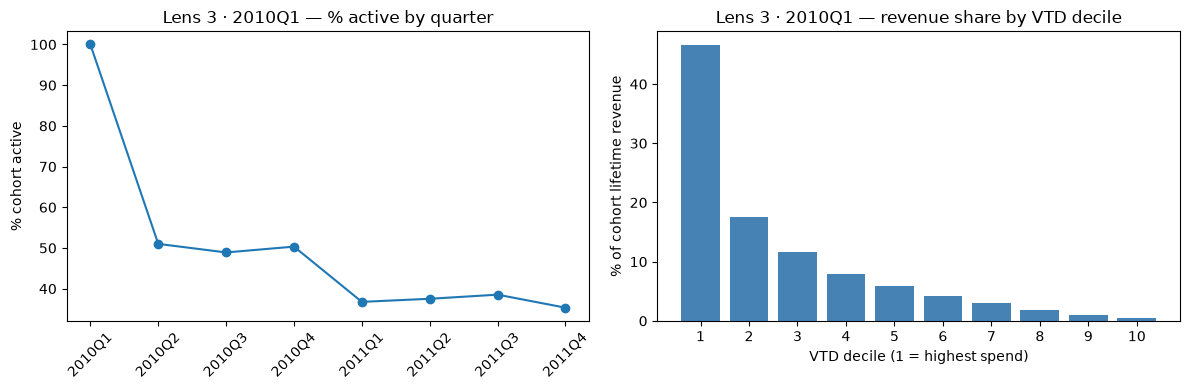

In [10]:
cohorts = sorted(orders["cohort_id"].unique())
# Prefer an early full quarter with enough customers (skip partial first if tiny)
sizes = orders.groupby("cohort_id")["customer_id"].nunique().sort_index()
display(sizes.rename("n_acquired").to_frame().T)
cohort_id = sizes.index[1] if len(sizes) > 1 and sizes.iloc[0] < sizes.iloc[1] * 0.3 else sizes.index[0]
# Prefer 2010Q1-ish if present
for pref in ("2010Q1", "2010Q2", "2009Q4"):
    if pref in sizes.index:
        cohort_id = pref
        break

print(f"Focal cohort: {cohort_id} (n={sizes[cohort_id]:,})")
print(f"% ever made a 2nd purchase: {ever_repeat_rate(orders, cohort_id):.1%}")

evo = cohort_evolution(orders, cohort_id, freq="Q")
display(evo.round(2))

gaps = interpurchase_gaps(orders, orders.loc[orders["cohort_id"] == cohort_id, "customer_id"].unique())
print(f"Interpurchase gaps (days): median={gaps.median():.0f} · mean={gaps.mean():.0f}")

sec = second_purchase_cumulative(orders, cohort_id)
display(sec.round(1))

vtd = vtd_deciles(orders, cohort_id)
print("VTD deciles (1 = highest lifetime spend in cohort):")
print("VTD = lifetime spend to date within this cohort; decile 1 = richest ~10%.")
display(vtd.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(evo["period"], evo["pct_active"], marker="o")
axes[0].set_ylabel("% cohort active")
axes[0].set_title(f"Lens 3 · {cohort_id} — % active by quarter")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(vtd["decile"].astype(str), vtd["pct_vtd"], color="steelblue")
axes[1].set_xlabel("VTD decile (1 = highest spend)")
axes[1].set_ylabel("% of cohort lifetime revenue")
axes[1].set_title(f"Lens 3 · {cohort_id} — revenue share by VTD decile")
plt.tight_layout()
plt.show()


#### Assessment — Lens 3 (focal early cohort)

- Early cohorts are large (e.g. **2010Q1 ≈ 1,186** acquired; **2009Q4 ≈ 950**).
- Ever-repeat is high for early cohorts (**~85–91%** make a 2nd purchase sometime) — trial→repeat conversion is strong over the full window.
- % active by quarter falls after acquisition, then **bounces in Q4s** (seasonality), matching the Lens 5 stack.
- **VTD deciles:** top ~10% of the cohort (decile 1) hold on the order of **~45–50%** of that cohort’s lifetime £; bottom deciles barely move the total.

**Implication:** acquisition quality looks good on ever-repeat; the management problem is keeping people active quarter-to-quarter, not only getting a second buy someday — and value inside the cohort is as skewed as the overall base.


### Lens 4 — Cohort comparison

**Focus:** Relative quality of later vs earlier acquisition cohorts after normalizing for size and age.

Pick 2–3 sizable acquisition quarters and overlay `cohort_evolution` metrics:

| Panel | Metric | For planning |
|-------|--------|--------------|
| % active | Active / acquired | Retention shape |
| AOF | Orders among actives | Depth of buying |
| AOV | £ among actives | Ticket size |

**Commercial read:** raw active counts mislead (big cohorts always look “healthier”). Size-normalized % active and AOF/AOV are the fair comparison.


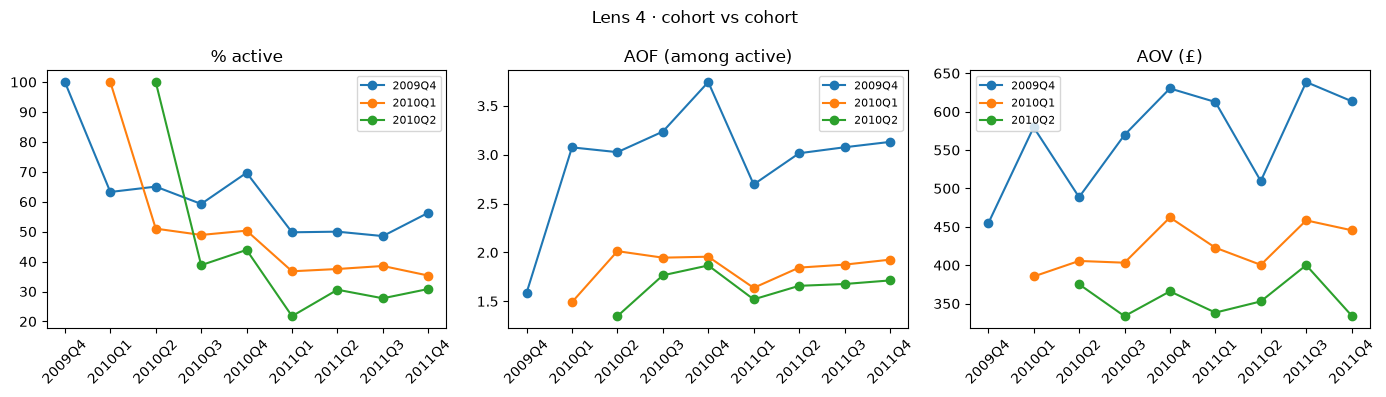

2009Q4: acquired=950 · ever-repeat=91.4%
2010Q1: acquired=1,186 · ever-repeat=84.7%
2010Q2: acquired=804 · ever-repeat=77.5%


In [11]:
# Pick three sizable cohorts
top = sizes.sort_values(ascending=False).head(8).index.tolist()
compare = []
for cid in sorted(top)[:3]:
    compare.append(cid)
# ensure we have distinct quarters
compare = sorted(set(compare))[:3]
if len(compare) < 2:
    compare = list(sizes.index[:3])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for cid in compare:
    e = cohort_evolution(orders, cid, freq="Q")
    axes[0].plot(e["period"], e["pct_active"], marker="o", label=cid)
    axes[1].plot(e["period"], e["aof"], marker="o", label=cid)
    axes[2].plot(e["period"], e["aov"], marker="o", label=cid)
axes[0].set_title("% active")
axes[1].set_title("AOF (among active)")
axes[2].set_title("AOV (£)")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
plt.suptitle("Lens 4 · cohort vs cohort")
plt.tight_layout()
plt.show()

for cid in compare:
    print(f"{cid}: acquired={sizes[cid]:,} · ever-repeat={ever_repeat_rate(orders, cid):.1%}")


#### Assessment — Lens 4

- We overlay **3** sizable early cohorts (`2009Q4`, `2010Q1`, `2010Q2`) on purpose — more lines hurt readability (Lens 5 shows all cohorts).
- All three start at **100% active** in their acquisition quarter, then decay with similar seasonal Q4 lifts.
- **2009Q4** often shows higher AOF/AOV among actives than later cohorts in the overlay — older survivors who still buy tend to be deeper/higher ticket (selection + tenure).
- Ever-repeat: **2009Q4 ~91%**, **2010Q1 ~85%**, **2010Q2 ~78%** — later of these three looks a bit weaker on lifetime second-buy conversion (also less follow-up calendar in-sample for the newest).

**Implication:** compare shapes (% active), not raw counts. Cohort quality is not identical; early cohorts look stickier on ever-repeat and richer among remaining actives.


### Lens 5 — Base health

**Focus:** Whether the active base is sustained by older cohorts, continuous refresh, or both.

| Object | Approach | Implication |
|--------|----------|-------------|
| `stacked_active_by_cohort` | For each calendar quarter: count **distinct customers with ≥1 order in that quarter**, split by their **acquisition** cohort | Whether recent cohorts replace aging ones |
| Planning sketch | Apply Lens-2 repeat-buying rate to current actives | Rough “how many new actives to stand still” (illustrative, **not** a CLV forecast) |

**Note:** a cohort’s band can **grow** from one quarter to the next (e.g. into `2011Q4`). That is not new acquisitions and not a bug. Cohort membership is fixed at first purchase; the band height is **how many of those people bought again in that quarter**. Giftware seasonality (Q4) often reactivates older cohorts, so `2010Q2` / `2010Q4` / `2009Q4` layers can thicken in later Q4s even while their acquisition quarter stays the tallest peak for that cohort.

The stacked area chart answers “who is keeping the lights on?” Forward £ / customer value is deferred to notebook `01`.


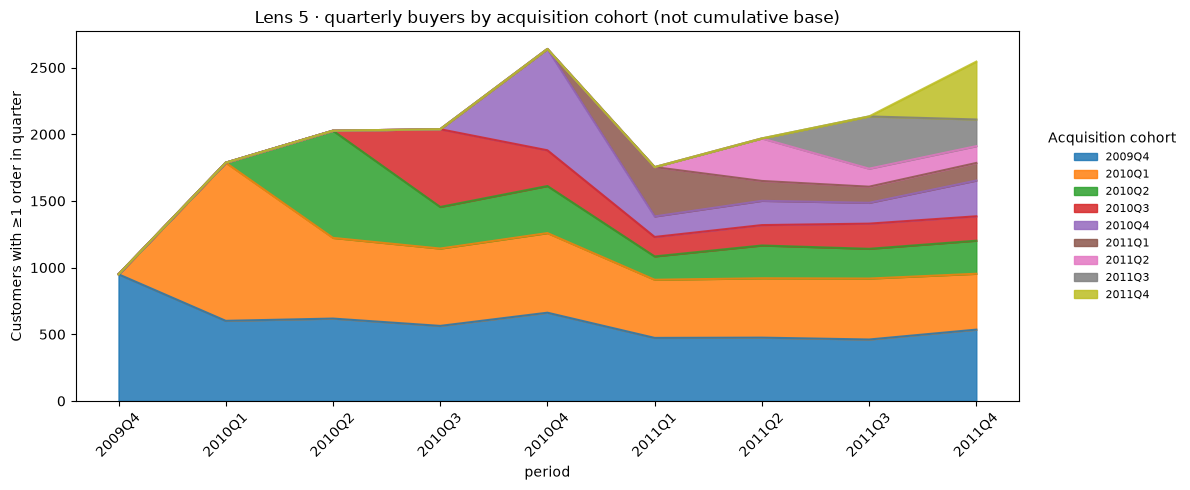

Top cohorts by total active-customer-quarters:


,active_customer_quarters
cohort_id,
2009Q4,5338.0
2010Q1,4725.0
2010Q2,2361.0
2010Q3,1522.0
2010Q4,1520.0
2011Q1,772.0
2011Q3,592.0
2011Q2,580.0



Rough planning (illustrative, not a forecast):
  Recent repeat-buying rate ≈ 63.1%
  If 4,170 actives this year and that rate holds, ~2,630 return next year
  To stand still at 4,170 actives would need ~1,540 newly active
Next: fit forward-looking CLV in Notebooks/01-clv.ipynb (BG/NBD + Gamma-Gamma on this order spine).


In [12]:
stacked = stacked_active_by_cohort(orders, freq="Q")
pivot = stacked.pivot_table(index="period", columns="cohort_id", values="n_active", fill_value=0)
# keep readable: drop tiny cohorts for plot
col_sums = pivot.sum().sort_values(ascending=False)
keep = sorted(col_sums.head(10).index)  # chronological for readable stack + legend
pivot_plot = pivot[keep]

fig, ax = plt.subplots(figsize=(12, 5))
pivot_plot.plot.area(ax=ax, stacked=True, alpha=0.85)
ax.set_ylabel("Customers with ≥1 order in quarter")
ax.set_title("Lens 5 · quarterly buyers by acquisition cohort (not cumulative base)")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Acquisition cohort", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print("Top cohorts by total active-customer-quarters:")
display(col_sums.head(8).rename("active_customer_quarters").to_frame())

# Back-of-envelope: if repeat rate from A→B holds, how many new customers to stand still?
rbr = repeat_buying_rate(orders, (p0_start, p0_end), (p1_start, p1_end))
n_b = cmp["n_active_b"]
expected_from_existing = rbr * n_b  # rough: apply prior repeat rate to current base
print(f"\nRough planning (illustrative, not a forecast):")
print(f"  Recent repeat-buying rate ≈ {rbr:.1%}")
print(f"  If {n_b:,} actives this year and that rate holds, ~{expected_from_existing:,.0f} return next year")
print(f"  To stand still at {n_b:,} actives would need ~{max(n_b - expected_from_existing, 0):,.0f} newly active")
print("Next: fit forward-looking CLV in Notebooks/01-clv.ipynb (BG/NBD + Gamma-Gamma on this order spine).")


#### Assessment — Lens 5

- Total quarterly buyers rise into peak seasons; the stack shows **continuous refresh** — new cohort bands appear each quarter while older bands shrink then partially recover.
- Older cohorts **thickening in 2011Q4** is reactivation (Christmas), not new members joining those cohorts.
- Planning sketch (illustrative): with **~63%** repeat-buying and **~4,170** current-year actives, expect **~2,630** returners next year → need on the order of **~1,540 newly active** just to stand still on headcount.

**Implication:** base health depends on both retaining prior buyers and acquiring/reactivating enough new actives. Forward £ value per customer is the job of `01-clv`, not this chart.


## Downstream handoff

Artifacts under `data/modeling/audit/` feed weekly CLV. Notebook `01` does **not** re-aggregate lines — it loads the order spine and runs the weekly 45/20/35 fit–val–test protocol.

| Artifact | Path | Consumed by |
|----------|------|-------------|
| Orders | `data/modeling/audit/uci_orders.parquet` | Weekly CLV cal / holdout RFM |
| Master | `data/modeling/audit/uci_customer_master.parquet` | Commercial customer table |
| Lifetime | `data/modeling/audit/uci_customer_lifetime.parquet` | Seg / VTD validation |
| Acquisition | `data/modeling/audit/uci_monthly_acquisition.parquet` | Growth tracking |
| Period panel | `data/modeling/audit/uci_customer_period_Q.parquet` | Cohort / period analyses |
| Stacked actives | `data/modeling/audit/uci_active_by_cohort_Q.parquet` | Lens 5 / base health |
| Lens-1 summary | `data/modeling/audit/uci_lens1_summary.parquet` | One-row health snapshot |
| Whale curve | `data/modeling/audit/uci_whale_curve.parquet` | Concentration dashboards |
| CLV scores (after `01`) | `models/01_clv_customer_scores.parquet` | Forward value, `p_alive`, segments |

**Handoff:** `Notebooks/01-clv.ipynb` — weekly BG/NBD (Fader–Hardie–Lee) + Gamma-Gamma; acceptance gate ≤ 5% aggregate error on unseen test revenue.
